In [2]:
# ---------- Cell 1 : 基础配置与依赖导入 ----------
import os
import re
import random
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
import sys
import pykeen.pipeline as pk_pipeline

# ========= 1. 基础配置 ========= #
INPUT_CSV = "NACC诊断.csv"
PREFIX = "distmult_NACC" 

EMBED_DIM = 32
SEED = 2025
FEATURE_START_IDX = 3  # 根据NACC特征顺序，特征从索引3(age)开始

# 严格剔除的标签 (包含元数据与目标泄露数据)
EXCLUDE_COLS = {
    'path', 'filename', 'ID', 
    'NC', 'MCI', 'DE', 'COG', 'AD', 
    'cdr', 'cdrSum', 'mmse', 'moca'
}

# 中间训练用的 TSV 文件
TRIPLE_TRAIN = f"train_{PREFIX}.tsv"
TRIPLE_VALID = f"valid_{PREFIX}.tsv"
TRIPLE_TEST = f"test_{PREFIX}.tsv"

# 按照要求修改最终输出的模型和映射文件名称
ENTITY2ID_PATH = "CustomKG-NACC.txt"
REL2ID_PATH = "relation2id_CustomKG-NACC.txt" 
EMB_PATH = "CustomKG-NACC.npy"

# 固定随机种子
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Cell 1: 基础配置与依赖加载完成。输出文件已设定为 CustomKG-NACC 系列。")

✅ Cell 1: 基础配置与依赖加载完成。输出文件已设定为 CustomKG-NACC 系列。


In [3]:
# ---------- Cell 2 : 辅助函数与特征图谱构建 ----------
def sanitize(text: str) -> str:
    return re.sub(r"\s+", "_", str(text).strip())

def age_bin(age):
    try:
        a = float(age)
    except:
        return "age_unknown"
    lo = int(a // 10 * 10)
    return f"age_{lo}_{lo + 9}"

def get_triples_for_patient(row: pd.Series):
    h = sanitize(row['ID'])
    feature_triples = []

    if "gender" in row and pd.notna(row["gender"]):
        feature_triples.append((h, "has_gender", sanitize(row["gender"])))
    if "age" in row and pd.notna(row["age"]):
        feature_triples.append((h, "has_age_bin", age_bin(row["age"])))

    for col in row.index[FEATURE_START_IDX:]:
        if col in EXCLUDE_COLS or col.lower() in ['age', 'gender', 'id']:
            continue

        v = row[col]
        if pd.isna(v) or str(v).strip() in ("", "nan"):
            continue

        col_name = sanitize(col)
        val_str = sanitize(v)
        feature_triples.append((h, f"has_{col_name}", val_str))

    return feature_triples

print(f">> Loading data from {INPUT_CSV} ...")
if not Path(INPUT_CSV).exists():
    print(f"Error: File not found {INPUT_CSV}")
else:
    df = pd.read_csv(INPUT_CSV)
    
    if 'ID' not in df.columns:
        raise ValueError(f"{INPUT_CSV} 中缺少 'ID' 列，无法提取锚点实体")
    
    all_triples = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="   Parsing Data"):
        feats = get_triples_for_patient(row)
        all_triples.extend(feats)
        
    print(f"\n✅ Cell 2: 数据解析完成。共提取到无监督特征三元组总数: {len(all_triples)}")

>> Loading data from NACC诊断.csv ...


   Parsing Data:   0%|          | 0/3708 [00:00<?, ?it/s]

   Parsing Data: 100%|██████████| 3708/3708 [00:00<00:00, 4158.56it/s]


✅ Cell 2: 数据解析完成。共提取到无监督特征三元组总数: 291673


In [4]:
# ---------- Cell 3 : 随机切分三元组与保存中间文件 ----------
# 随机打乱三元组
random.shuffle(all_triples)

n_total = len(all_triples)
n_test = int(n_total * 0.10)
n_valid = int(n_total * 0.10)

final_test = all_triples[:n_test]
final_valid = all_triples[n_test:n_test + n_valid]
final_train = all_triples[n_test + n_valid:]

print(f"\n>> Triples Stats:")
print(f"   Train Triples: {len(final_train):,}")
print(f"   Valid Triples: {len(final_valid):,}")
print(f"   Test  Triples: {len(final_test):,}")

# 保存为 PyKeen 需要的 TSV 格式
def save_tsv(path, triples):
    with open(path, "w", encoding="utf-8") as f:
        for h, r, t in triples: 
            f.write(f"{h}\t{r}\t{t}\n")

save_tsv(TRIPLE_TRAIN, final_train)
save_tsv(TRIPLE_VALID, final_valid)
save_tsv(TRIPLE_TEST, final_test)

print("\n✅ Cell 3: 数据集切分与 TSV 保存完成，准备进入模型训练。")


>> Triples Stats:
   Train Triples: 233,339
   Valid Triples: 29,167
   Test  Triples: 29,167

✅ Cell 3: 数据集切分与 TSV 保存完成，准备进入模型训练。


In [7]:
# ---------- Cell 4 : PyKeen 训练、提取 Loss、嵌入保存与规模统计 ----------
import os
import torch
import numpy as np

print("\n>> Starting DistMult training ...")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Using device: {device}")

result = pk_pipeline.pipeline(
    model="DistMult",
    training=TRIPLE_TRAIN,
    validation=TRIPLE_VALID,
    testing=TRIPLE_TEST,
    model_kwargs=dict(embedding_dim=EMBED_DIM),
    training_kwargs=dict(num_epochs=50, batch_size=2048),
    stopper="early",
    stopper_kwargs=dict(frequency=5, patience=10, relative_delta=0.002),
    evaluator_kwargs=dict(filtered=True, batch_size=8),
    negative_sampler="basic",
    random_seed=SEED,
    device=device,
    training_loop="SLCWA",
)

print("\n>> Training Finished.")

train_losses = result.training_loop.losses_per_epochs
np.save("CustomKG-NACC-Losses.npy", train_losses)
print(f"✅ Training loss history saved. Total epochs run: {len(train_losses)}")

model = result.model
entity_embs = model.entity_representations[0]().cpu().detach().numpy()

np.save("CustomKG-NACC.npy", entity_embs)

with open("CustomKG-NACC.txt", "w", encoding="utf-8") as f:
    for e, i in result.training.entity_to_id.items():
        f.write(f"{e}\t{i}\n")

with open("relation2id_CustomKG-NACC.txt", "w", encoding="utf-8") as f:
    for r, i in result.training.relation_to_id.items():
        f.write(f"{r}\t{i}\n")

print(f"\n✅ All Done. Embeddings strictly saved to: CustomKG-NACC.npy")
print(f"✅ Entity mapping strictly saved to: CustomKG-NACC.txt")

print("\n==========================================")
print("          CustomKG 图谱规模统计")
print("==========================================")

total_triples_count = 0
unique_entities = set()
unique_relations = set()

for tsv_file in [TRIPLE_TRAIN, TRIPLE_VALID, TRIPLE_TEST]:
    if os.path.exists(tsv_file):
        with open(tsv_file, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 3:
                    h, r, t = parts
                    unique_entities.add(h)
                    unique_entities.add(t)
                    unique_relations.add(r)
                    total_triples_count += 1

print(f"总三元组数量: {total_triples_count:,}")
print(f"总节点数 (Entities): {len(unique_entities):,}")
print(f"总关系数 (Relations): {len(unique_relations):,}")
print(f"因果/诊断关系数: 0 (注：为防止下游多模态模型产生 Label Leakage，已严格剔除诊断边)")
print("==========================================")


>> Starting DistMult training ...
   Using device: cuda


INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: /home/xkj/.data/pykeen/checkpoints/best-model-weights-0a28e6d8-dc5a-4537-a1a8-c7c796406330.pt


Training epochs on cuda:0:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/114 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/114 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/114 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.43s seconds


Evaluating on cuda:0:   0%|          | 0.00/29.2k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.57s seconds



>> Training Finished.
✅ Training loss history saved. Total epochs run: 50

✅ All Done. Embeddings strictly saved to: CustomKG-NACC.npy
✅ Entity mapping strictly saved to: CustomKG-NACC.txt

          CustomKG 图谱规模统计
总三元组数量: 291,673
总节点数 (Entities): 4,003
总关系数 (Relations): 95
因果/诊断关系数: 0 (注：为防止下游多模态模型产生 Label Leakage，已严格剔除诊断边)


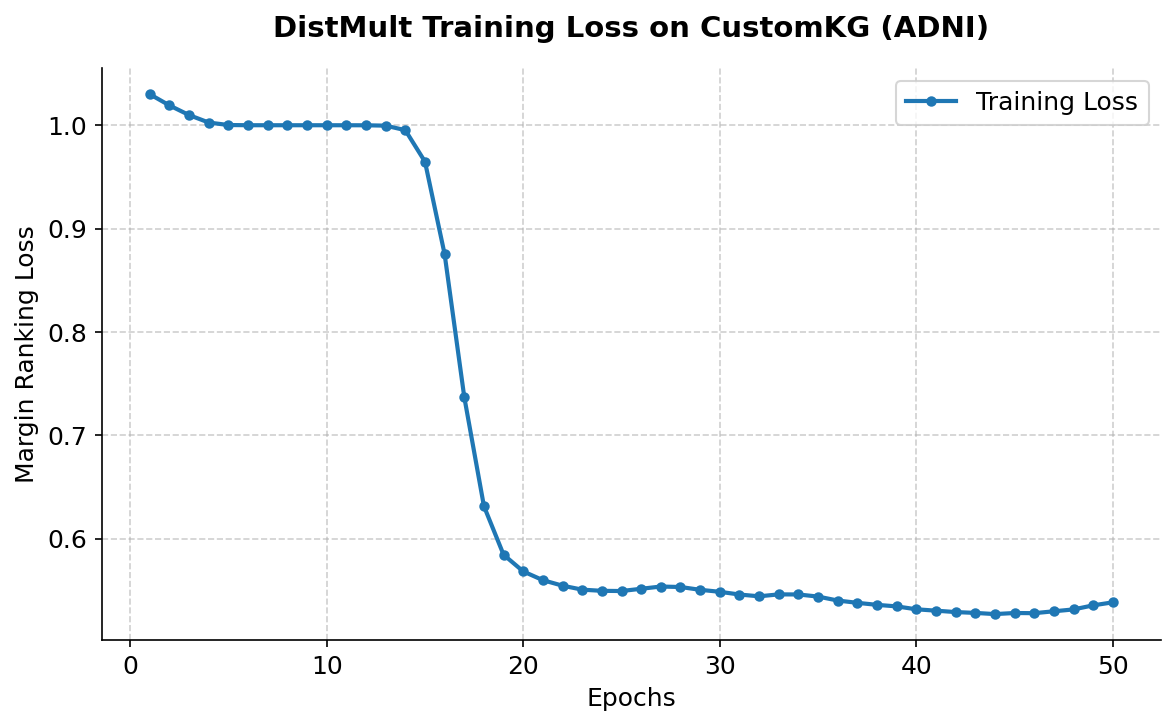

✅ Loss 曲线绘制完成！高清图像已保存至: CustomKG-ADNI-LossCurve.png


In [ ]:
# ---------- Cell 5 : 绘制并保存训练 Loss 曲线 ----------
import matplotlib.pyplot as plt
import numpy as np

# 读取 Cell 4 保存的 Loss 数据
try:
    train_losses = np.load("CustomKG-NACC-Losses.npy")
except FileNotFoundError:
    print("❌ 找不到 Loss 文件，请确保 Cell 4 已成功运行。")
    train_losses = []

if len(train_losses) > 0:
    # 设置全局字体大小，适应论文排版
    plt.rcParams.update({'font.size': 12})
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    
    # 绘制曲线
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, color='#1f77b4', linewidth=2, linestyle='-', marker='o', markersize=4, label='Training Loss')
    
    # 设置图表元素
    ax.set_title('DistMult Training Loss on CustomKG (ADNI)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Margin Ranking Loss', fontsize=12)
    
    # 优化视觉效果
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right')
    
    # 紧凑布局
    plt.tight_layout()
    
    # 保存为高质量图片供论文使用
    img_path = "CustomKG-NACC-LossCurve.png"
    plt.savefig(img_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Loss 曲线绘制完成！高清图像已保存至: {img_path}")